In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

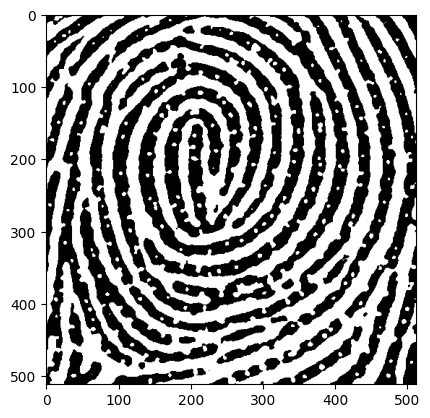

In [27]:
img = cv2.imread("../images/50_whorl.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.threshold(img, 127, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY)[1]

H = img.shape[0]
W = img.shape[1]

plt.imshow(img, cmap='gray')

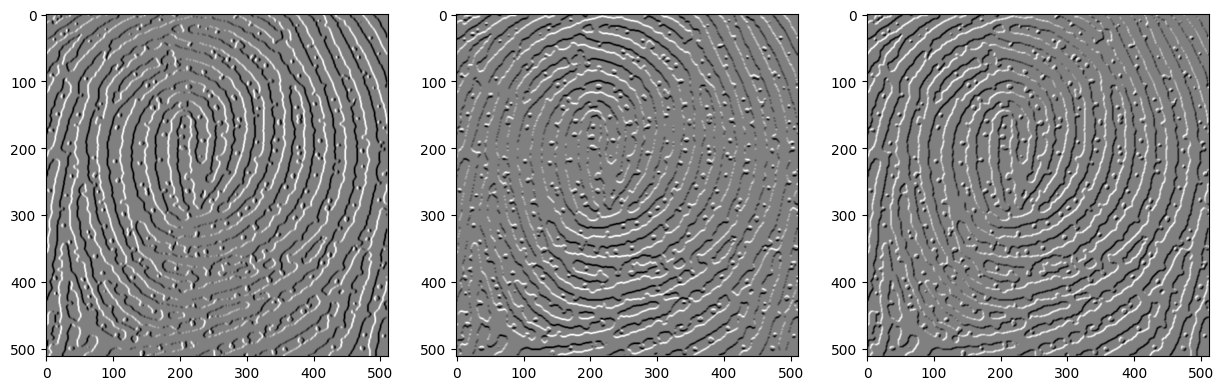

In [28]:
edge_horiz = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
edge_vert = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(edge_horiz, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(edge_vert, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(edge_horiz + edge_vert, cmap='gray')

In [29]:
I = cv2.GaussianBlur(img, (3, 3), 1.5)

J11 = cv2.boxFilter(edge_horiz * edge_horiz, cv2.CV_64F, (16, 16))
J22 = cv2.boxFilter(edge_vert * edge_vert, cv2.CV_64F, (16, 16))
J12 = cv2.boxFilter(edge_horiz * edge_vert, cv2.CV_64F, (16, 16))

theta = 0.5 * np.arctan2(2 * J12, J11 - J22)
theta

array([[ 1.45960809,  1.45960809,  1.45330248, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.45960809,  1.45960809,  1.45330248, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.44878665,  1.44878665,  1.45778823, ..., -0.78539816,
         0.        ,  0.        ],
       ...,
       [ 0.12092515,  0.12092515,  0.11543732, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.13480645,  0.13480645,  0.14369624, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1506232 ,  0.1506232 ,  0.17176691, ...,  0.        ,
         0.        ,  0.        ]], shape=(512, 512))

In [30]:
coh = np.sqrt((J11 - J22) ** 2 + 4 * J12**2) / (J11 + J22 + 1e-8)

block = 16
f_map = np.full_like(I, np.nan, dtype=float)

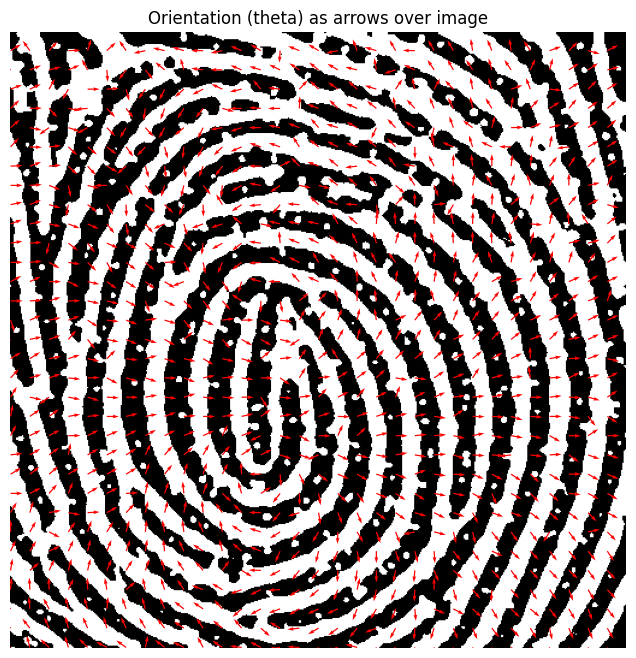

In [31]:
# Choose a stride equal to the block size to make arrows readable
stride = 16
ys = np.arange(0, theta.shape[0], stride)
xs = np.arange(0, theta.shape[1], stride)
X, Y = np.meshgrid(xs, ys)
# Sample the theta values at the grid points (rows, cols)
theta_sample = theta[Y, X]
# Compute arrow components (cos, sin) — these point along the orientation
U = np.cos(2 * theta_sample)
V = np.sin(2 * theta_sample)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
# quiver expects X,Y in image coords (cols, rows) — so pass X and Y
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=0.1, width=0.002)
plt.gca().invert_yaxis()
plt.title('Orientation (theta) as arrows over image')
plt.axis('off')
plt.show()

In [32]:
import matplotlib.pyplot as plt


def quiver_theta(theta, img=None, stride=16, scale=1.0, width=0.002, color="r", highlight_blocks=False):
    H, W = theta.shape
    nb_x, nb_y = W // stride, H // stride

    ys = np.arange(0, H, stride)
    xs = np.arange(0, W, stride)
    X, Y = np.meshgrid(xs, ys)

    th_s = theta[Y, X]
    # Orientation is π-periodic → use 2θ to get a direction vector
    U = np.cos(th_s)
    V = np.sin(th_s)

    plt.figure(figsize=(8, 8))
    if img is not None:
        plt.imshow(img, cmap="gray")
        
    plt.quiver(
        X,
        Y,
        U,
        V,
        color=color,
        angles="xy",
        scale_units="xy",
        scale=scale,
        width=width,
        headaxislength=0,
        headlength=0,
        headwidth=0,
    )

    # Highlight the blocks with cyan squares
    if highlight_blocks:
        for i in range(nb_y):
            for j in range(nb_x):
                rect = plt.Rectangle(
                    (j * stride, i * stride),  # bottom-left corner
                    stride,
                    stride,  # width, height
                    linewidth=1,
                    edgecolor="cyan",
                    facecolor="none",
                    alpha=0.3,
                )
                plt.gca().add_patch(rect)

    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.show()

In [33]:
H, W = img.shape
w = 16  # Block size

Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

Gx2 = Gx * Gx
Gy2 = Gy * Gy
Gxy = Gx * Gy

sum_Gx2 = cv2.boxFilter(Gx2, -1, (w, w), normalize=False)
sum_Gy2 = cv2.boxFilter(Gy2, -1, (w, w), normalize=False)
sum_Gxy = cv2.boxFilter(Gxy, -1, (w, w), normalize=False)

# Vx = sum_Gxy[w // 2 :: w, w // 2 :: w] * 2  # The original paper uses 2 * sum_Gxy
# Vy = sum_Gx2[w // 2 :: w, w // 2 :: w] - sum_Gy2[w // 2 :: w, w // 2 :: w]

Vx = 2 * sum_Gxy
Vy = sum_Gx2 - sum_Gy2

theta = 0.5 * np.arctan2(Vx, Vy) + np.pi/2
print(theta.shape)
print(theta)

(512, 512)
[[3.10593892 3.10593892 3.10593892 ... 1.57079633 1.57079633 1.57079633]
 [3.10593892 3.10593892 3.10593892 ... 1.57079633 1.57079633 1.57079633]
 [3.08415435 3.08415435 3.09671357 ... 1.57079633 1.57079633 1.57079633]
 ...
 [1.64909727 1.64909727 1.64859374 ... 1.57079633 1.57079633 1.57079633]
 [1.65698593 1.65698593 1.67985787 ... 1.57079633 1.57079633 1.57079633]
 [1.68359695 1.68359695 1.72660665 ... 1.57079633 1.57079633 1.57079633]]


In [34]:
# plt.figure(figsize=(10, 10))
# plt.imshow(img, cmap="gray")

# stride = w  # Stride is the same as the block size
# ys, xs = np.indices(theta.shape) * stride + stride // 2
# U = np.cos(theta)
# V = np.sin(theta)

# plt.quiver(
#     xs,
#     ys,
#     U,
#     V,
#     color="red",
#     angles="xy",
#     scale_units="xy",
#     scale=0.07,
#     width=0.003,
#     headaxislength=0,
#     headlength=0,
#     headwidth=0,
# )

# plt.gca().invert_yaxis()
# plt.title("Blockwise Dominant Ridge Orientation")
# plt.axis("off")
# plt.show()

In [35]:
Tx = np.cos(2 * theta)
Ty = np.sin(2 * theta)

Tprime_x = cv2.GaussianBlur(Tx, (5, 5), 0)
Tprime_y = cv2.GaussianBlur(Ty, (5, 5), 0)

theta_smoothed = 0.5 * np.arctan2(Tprime_y, Tprime_x)
print(theta_smoothed.shape)
print(theta_smoothed)

(512, 512)
[[-0.03818005 -0.03859585 -0.07050256 ...  1.5668594   1.57079633
   1.57079633]
 [-0.04723487 -0.04699073 -0.07290773 ...  1.55258576  1.56883555
   1.57079633]
 [-0.08130426 -0.07976552 -0.09307238 ...  1.50601384  1.56144705
   1.57079633]
 ...
 [-1.4891814  -1.48847674 -1.4891502  ...  1.57079633  1.57079633
   1.57079633]
 [-1.4780362  -1.4751036  -1.47205725 ...  1.57079633  1.57079633
   1.57079633]
 [-1.47218122 -1.46794499 -1.46270977 ...  1.57079633  1.57079633
   1.57079633]]


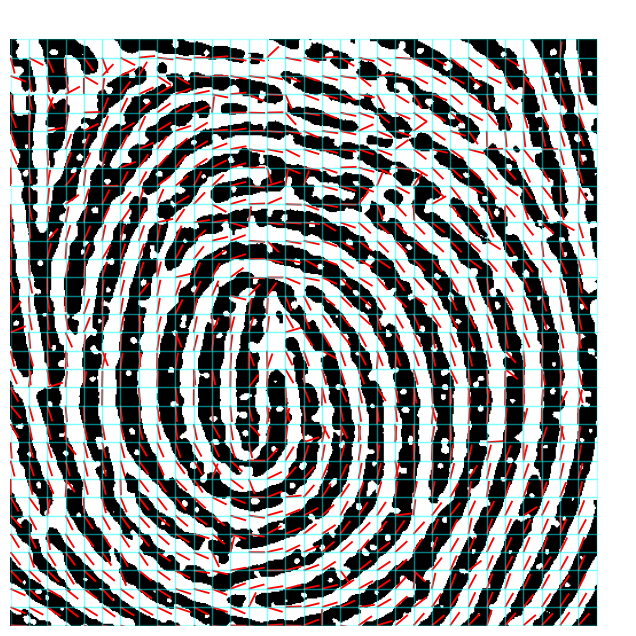

In [36]:
quiver_theta(
    theta_smoothed,
    img=img,
    stride=16,
    scale=0.07,
    width=0.003,
    color="red",
    highlight_blocks=True,
)